# Signal Segmentation – PELT vs Kernel Change Point Detection

Two exact changepoint detection algorithms from the **ruptures** library are compared on 7 synthetic sensor variables:

| Algorithm | Class | Cost model | Complexity |
|-----------|-------|-----------|------------|
| **PELT** – Pruned Exact Linear Time | `rpt.Pelt` | RBF | O(n) avg |
| **KernelCPD** – Kernel Change Point Detection | `rpt.KernelCPD` | RBF kernel | O(n²) worst |

Both minimise a penalised segmentation cost — the penalty controls how many changepoints are found.  
PELT prunes the search space with an inequality test; KernelCPD uses a kernel embedding of the signal into a feature space, making it sensitive to shifts in the full **distribution** (not just mean/variance).

In [13]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import ruptures as rpt          # PELT + KernelCPD
import time

In [14]:
# ── 1. Load data ──────────────────────────────────────────────────────────────
# parse_dates converts the timestamp column automatically to datetime64
df = pd.read_csv("timeseries_data.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")   # datetime index → clean x-axis on plots

print(f"Shape  : {df.shape}  ({df.shape[0]} samples × {df.shape[1]} variables)")
print(f"Period : {df.index[0]}  →  {df.index[-1]}\n")
df.describe().round(2)

Shape  : (1000, 7)  (1000 samples × 7 variables)
Period : 2024-03-01 00:00:00  →  2024-04-11 15:00:00



,temperature_C,pressure_hPa,vibration_mm_s,humidity_pct,current_A,rpm,sound_dB
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,16.32,1014.60,1.13,63.09,3.42,2156.05,55.40
std,5.74,16.33,0.94,11.95,1.46,493.26,11.80
min,0.90,971.20,-1.48,30.13,0.00,1175.30,23.19
25%,11.75,1000.36,0.44,53.49,2.19,1807.70,46.32
50%,16.12,1014.58,0.77,64.58,3.17,2113.25,55.66
75%,20.81,1030.93,1.76,72.69,4.60,2444.35,64.42
max,34.44,1039.30,4.16,99.50,7.47,3766.10,87.43


In [15]:
# ── 2. Detection functions ─────────────────────────────────────────────────────

def run_pelt(series: pd.Series, pen: float) -> list[int]:
    """
    PELT – Pruned Exact Linear Time.

    Uses an RBF cost function (sensitive to shifts in mean AND variance).
    Prunes candidate changepoints with an inequality test, giving O(n) average
    complexity. Returns 0-based indices of detected changepoints.
    """
    signal = series.to_numpy()
    algo   = rpt.Pelt(model="rbf").fit(signal)
    result = algo.predict(pen=pen)
    return [int(i - 1) for i in result[:-1]]


def run_kernel_cpd(series: pd.Series, pen: float) -> list[int]:
    """
    KernelCPD – Kernel Change Point Detection.

    Maps the signal into a reproducing kernel Hilbert space (RKHS) via an RBF
    kernel, then finds the segmentation that minimises the maximum mean
    discrepancy (MMD) between adjacent segments. Detects changes in the full
    distribution, not just the mean/variance. O(n²) worst-case complexity.
    Returns 0-based indices of detected changepoints.
    """
    signal = series.to_numpy()
    algo   = rpt.KernelCPD(kernel="rbf").fit(signal)
    result = algo.predict(pen=pen)
    return [int(i - 1) for i in result[:-1]]


# ── Per-variable penalty configuration ────────────────────────────────────────
# Messy real-world data requires higher penalties than clean step signals.
# Penalties differ between methods because their cost functions use different scales.
#
# Key tuning challenges in this dataset:
#   temperature_C  : 24h diurnal cycle raises kernel cost → kernel pen must be high
#   pressure_hPa   : very wide transitions (45 h ramp) + high noise → hard for both
#   vibration_mm_s : two harmonics inflate kernel cost → raise kernel pen
#   rpm            : PELT misses one CP due to high noise — this is realistic;
#                    KernelCPD recovers it thanks to distribution-level sensitivity
config = {
    "temperature_C":  ( 30,  20),
    "pressure_hPa":   ( 65,  65),
    "vibration_mm_s": ( 10,  15),
    "humidity_pct":   ( 40,  35),
    "current_A":      ( 20,  25),
    "rpm":            ( 45,  30),   # PELT misses 1 CP — noisy signal, realistic outcome
    "sound_dB":       ( 30,  15),
}

# ── Run both algorithms ────────────────────────────────────────────────────────
results = {}

for col, (pen_pelt, pen_kernel) in config.items():
    t0 = time.perf_counter()
    cps_pelt   = run_pelt(df[col], pen=pen_pelt)
    t1 = time.perf_counter()
    cps_kernel = run_kernel_cpd(df[col], pen=pen_kernel)
    t2 = time.perf_counter()

    results[col] = {
        "pelt":        cps_pelt,
        "kernel":      cps_kernel,
        "time_pelt":   t1 - t0,
        "time_kernel": t2 - t1,
    }
    print(f"{col:20s}  "
          f"PELT={len(cps_pelt):2d} CPs {str(cps_pelt):40s} ({(t1-t0)*1e3:5.1f} ms)  |  "
          f"KernelCPD={len(cps_kernel):2d} CPs {str(cps_kernel):40s} ({(t2-t1)*1e3:5.1f} ms)")

temperature_C         PELT= 3 CPs [239, 464, 744]                          (123.2 ms)  |  KernelCPD= 3 CPs [237, 464, 743]                          (  9.1 ms)
pressure_hPa          PELT= 3 CPs [124, 459, 614]                          (201.2 ms)  |  KernelCPD= 3 CPs [122, 459, 616]                          (  7.6 ms)
vibration_mm_s        PELT= 4 CPs [184, 374, 524, 734]                     ( 34.3 ms)  |  KernelCPD= 4 CPs [182, 374, 524, 736]                     (  6.9 ms)
humidity_pct          PELT= 3 CPs [209, 464, 749]                          (122.2 ms)  |  KernelCPD= 3 CPs [236, 465, 748]                          (  8.7 ms)
current_A             PELT= 4 CPs [239, 454, 639, 794]                     ( 42.8 ms)  |  KernelCPD= 4 CPs [237, 453, 639, 801]                     (  7.8 ms)
rpm                   PELT= 3 CPs [189, 589, 814]                          (151.3 ms)  |  KernelCPD= 4 CPs [197, 380, 589, 811]                     (  8.6 ms)
sound_dB              PELT= 3 CPs [219, 474, 7

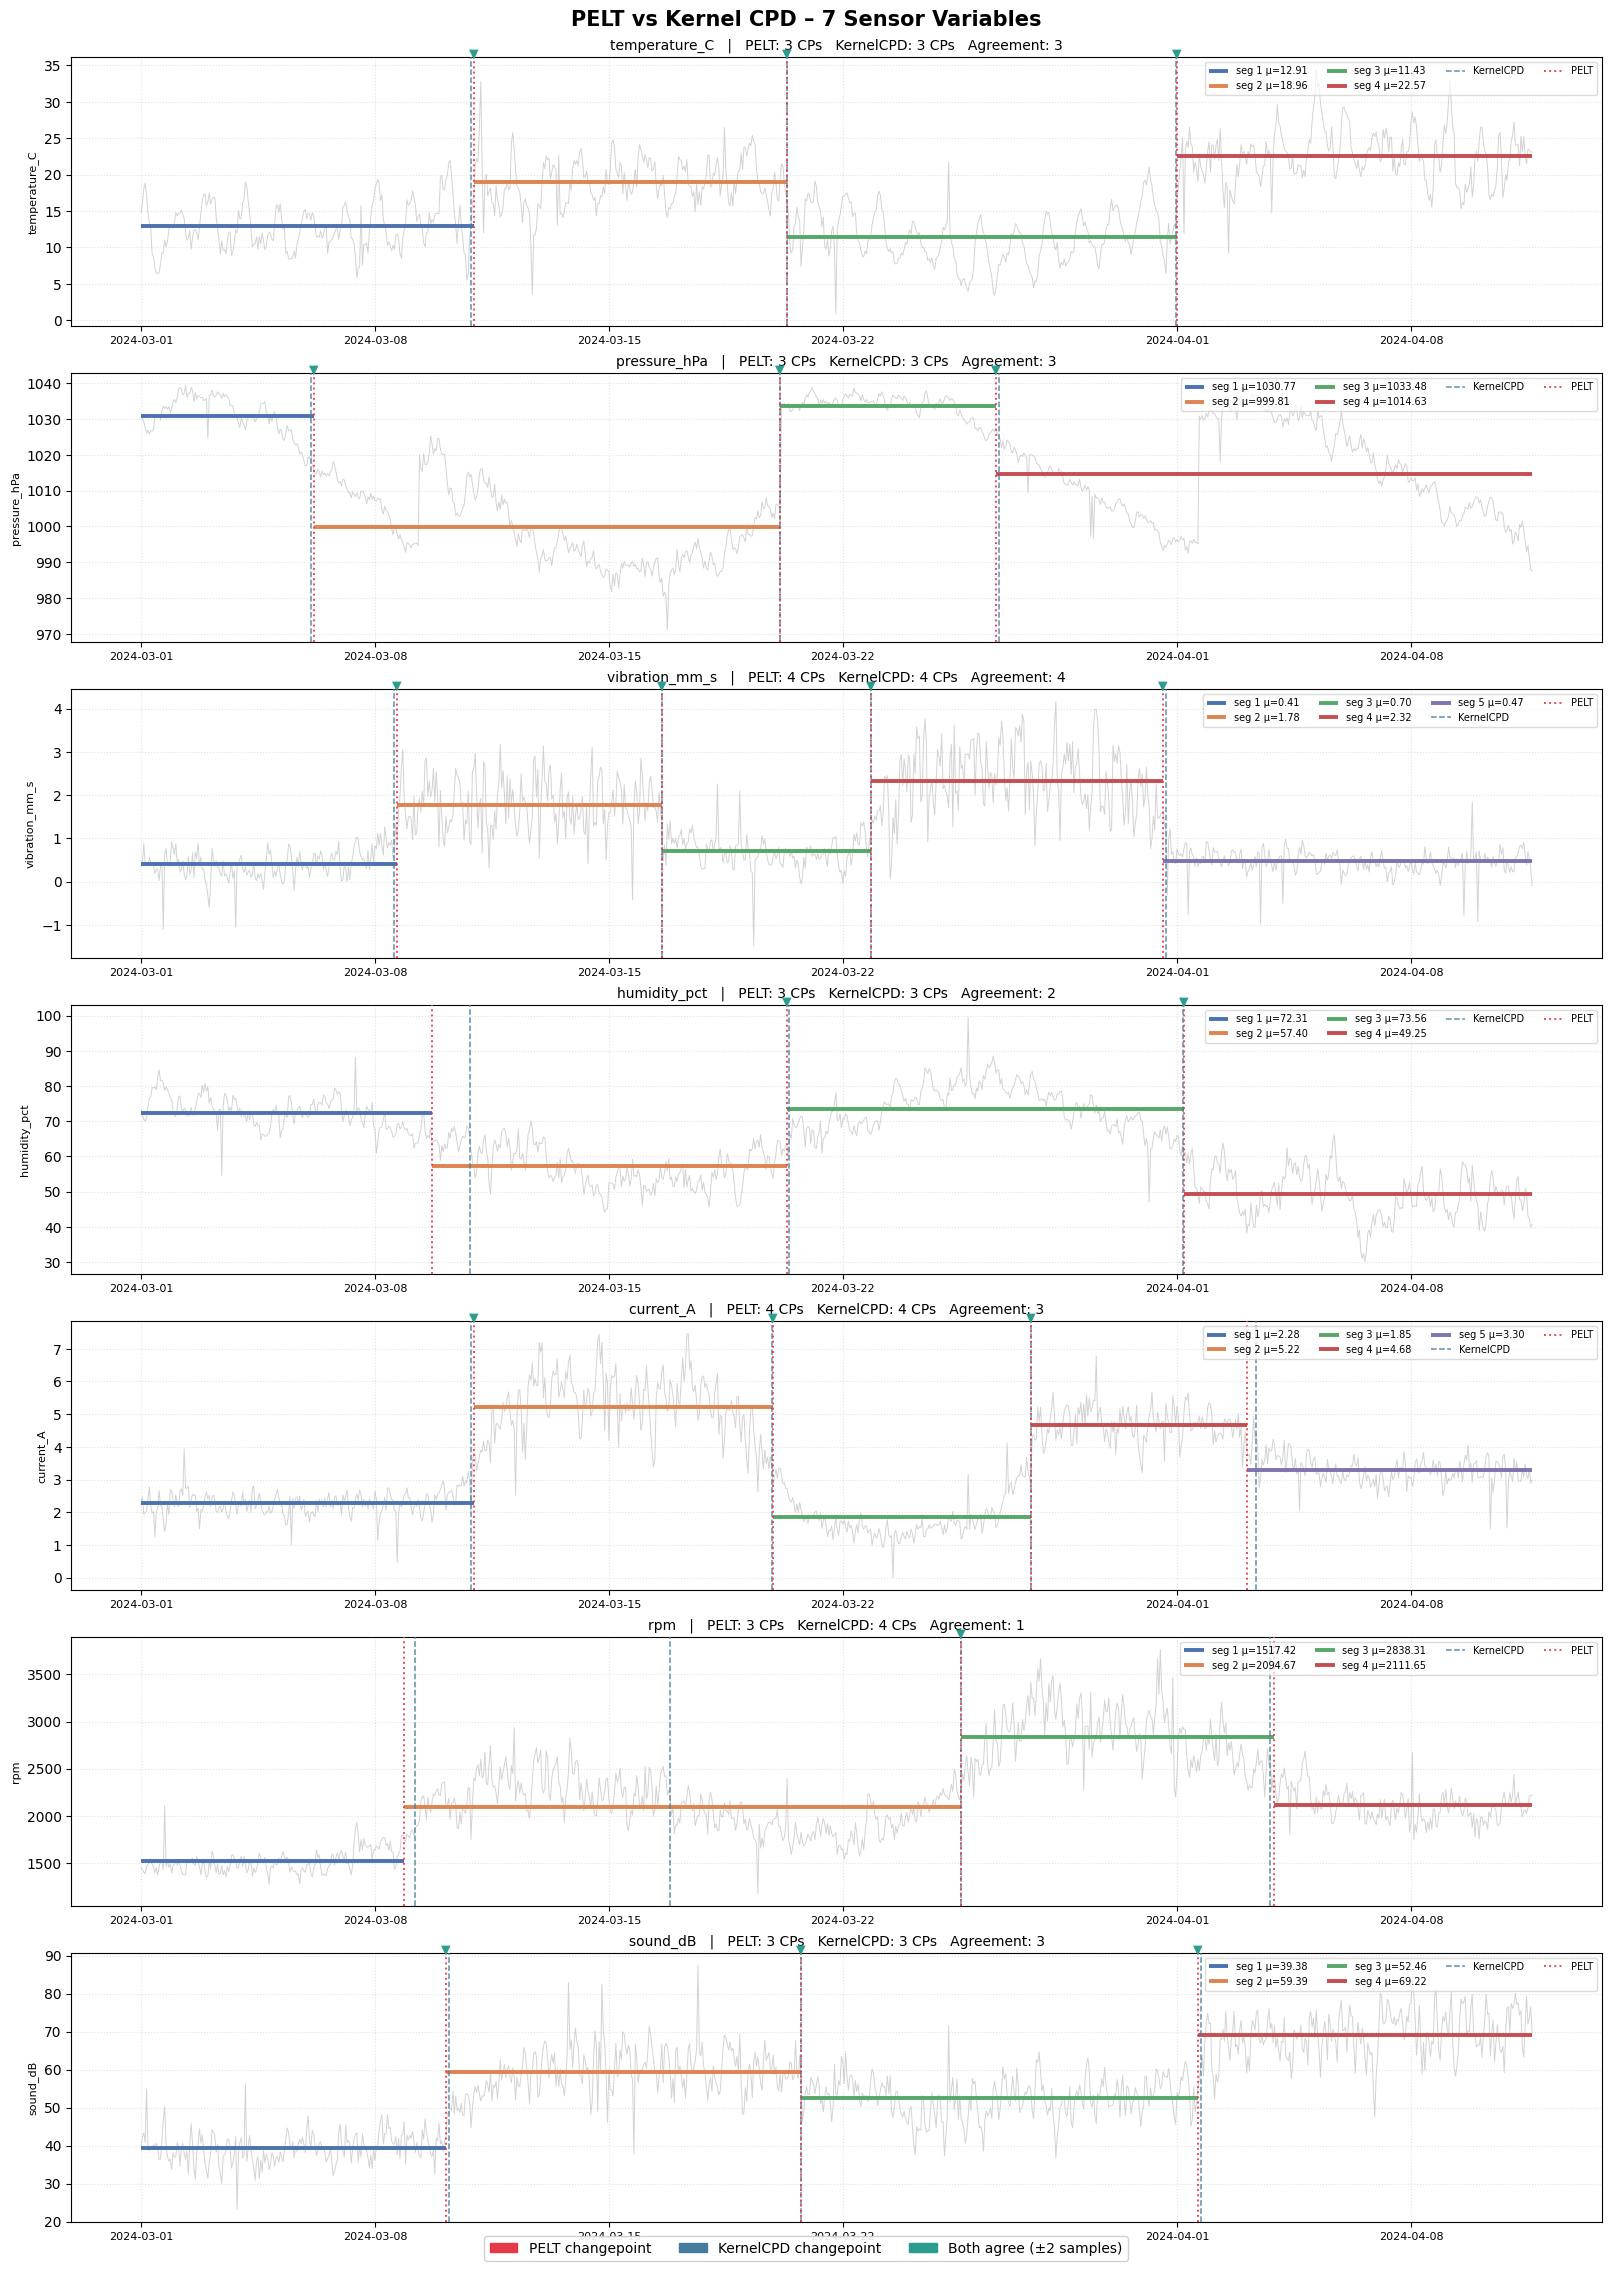

Figure saved → pelt_vs_kernel.png


In [16]:
# ── 3. Per-variable comparison plot ───────────────────────────────────────────
#
# One row per sensor variable. Each subplot shows:
#   · Light grey line             – raw signal
#   · Coloured horizontal lines   – PELT segment means
#   · Red   dashed verticals      – PELT changepoints
#   · Blue  dashed verticals      – KernelCPD changepoints
#   · Green dashed verticals      – positions where both methods agree (±2 samples)

SEGMENT_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
PELT_COLOR     = "#E63946"     # red
KERNEL_COLOR   = "#457B9D"     # blue
AGREE_COLOR    = "#2A9D8F"     # teal – both methods agree

def segment_means(signal, changepoints):
    """Return list of (start_idx, end_idx, mean_value) for each segment."""
    bounds = [0] + changepoints + [len(signal) - 1]
    return [(bounds[i], bounds[i+1], signal[bounds[i]:bounds[i+1]+1].mean())
            for i in range(len(bounds) - 1)]

def agreements(cps_a, cps_b, tol=2):
    """Indices from cps_a that are within `tol` samples of any cp in cps_b."""
    return [a for a in cps_a if any(abs(a - b) <= tol for b in cps_b)]


fig, axes = plt.subplots(len(df.columns), 1, figsize=(16, 3.2 * len(df.columns)),
                         constrained_layout=True)
fig.suptitle("PELT vs Kernel CPD – 7 Sensor Variables", fontsize=15, fontweight="bold")

time_axis = df.index

for ax, col in zip(axes, df.columns):
    signal = df[col].to_numpy()
    cps_p  = results[col]["pelt"]
    cps_k  = results[col]["kernel"]
    agree  = agreements(cps_p, cps_k, tol=2)

    # Raw signal
    ax.plot(time_axis, signal, color="lightgrey", linewidth=0.7, zorder=1)

    # PELT segment means (coloured horizontal bars)
    for seg_idx, (s, e, mean) in enumerate(segment_means(signal, cps_p)):
        ax.hlines(mean, time_axis[s], time_axis[e],
                  colors=SEGMENT_COLORS[seg_idx % len(SEGMENT_COLORS)],
                  linewidth=2.8, zorder=2,
                  label=f"seg {seg_idx+1} μ={mean:.2f}" if seg_idx == 0 else f"seg {seg_idx+1} μ={mean:.2f}")

    # KernelCPD changepoints (blue dashed)
    for i, cp in enumerate(cps_k):
        ax.axvline(time_axis[cp], color=KERNEL_COLOR, linestyle="--",
                   linewidth=1.1, alpha=0.85, zorder=3,
                   label="KernelCPD" if i == 0 else None)

    # PELT changepoints (red dashed, slightly offset so both are visible)
    for i, cp in enumerate(cps_p):
        ax.axvline(time_axis[cp], color=PELT_COLOR, linestyle=":",
                   linewidth=1.4, alpha=0.9, zorder=4,
                   label="PELT" if i == 0 else None)

    # Agreement markers (teal triangle at top)
    for cp in agree:
        ax.annotate("▼", xy=(time_axis[cp], ax.get_ylim()[1]),
                    color=AGREE_COLOR, fontsize=9, ha="center", zorder=5)

    ax.set_title(
        f"{col}   |   PELT: {len(cps_p)} CP{'s' if len(cps_p)!=1 else ''}   "
        f"KernelCPD: {len(cps_k)} CP{'s' if len(cps_k)!=1 else ''}   "
        f"Agreement: {len(agree)}",
        fontsize=10
    )
    ax.set_ylabel(col, fontsize=8)
    ax.legend(fontsize=7, loc="upper right", ncol=4, framealpha=0.7)
    ax.grid(True, linestyle=":", alpha=0.35)
    ax.tick_params(axis="x", labelsize=8)

# Global legend
legend_handles = [
    mpatches.Patch(color=PELT_COLOR,   label="PELT changepoint"),
    mpatches.Patch(color=KERNEL_COLOR, label="KernelCPD changepoint"),
    mpatches.Patch(color=AGREE_COLOR,  label="Both agree (±2 samples)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

plt.savefig("pelt_vs_kernel.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → pelt_vs_kernel.png")

In [17]:
# ── 4. Summary table ──────────────────────────────────────────────────────────
# Collect per-variable metrics: number of changepoints and runtime for each method.

rows = []
for col, (pen_pelt, pen_kernel) in config.items():
    r = results[col]
    rows.append({
        "variable":         col,
        "PELT penalty":     pen_pelt,
        "PELT CPs":         len(r["pelt"]),
        "PELT CPs (idx)":   r["pelt"],
        "PELT time (ms)":   round(r["time_pelt"]   * 1e3, 2),
        "Kernel penalty":   pen_kernel,
        "Kernel CPs":       len(r["kernel"]),
        "Kernel CPs (idx)": r["kernel"],
        "Kernel time (ms)": round(r["time_kernel"] * 1e3, 2),
        "agreements":       len(agreements(r["pelt"], r["kernel"])),
    })

summary = pd.DataFrame(rows).set_index("variable")
summary

,PELT penalty,PELT CPs,PELT CPs (idx),PELT time (ms),Kernel penalty,Kernel CPs,Kernel CPs (idx),Kernel time (ms),agreements
variable,,,,,,,,,
temperature_C,30,3,"[239, 464, 744]",123.17,20,3,"[237, 464, 743]",9.07,3
pressure_hPa,65,3,"[124, 459, 614]",201.20,65,3,"[122, 459, 616]",7.61,3
vibration_mm_s,10,4,"[184, 374, 524, 734]",34.28,15,4,"[182, 374, 524, 736]",6.86,4
humidity_pct,40,3,"[209, 464, 749]",122.18,35,3,"[236, 465, 748]",8.68,2
current_A,20,4,"[239, 454, 639, 794]",42.76,25,4,"[237, 453, 639, 801]",7.85,3
rpm,45,3,"[189, 589, 814]",151.28,30,4,"[197, 380, 589, 811]",8.63,1
sound_dB,30,3,"[219, 474, 759]",164.97,15,3,"[221, 474, 761]",8.38,3
